In [1]:
!python -m pip install vcdvcd

You should consider upgrading via the '/home/eng/a/axm200085/SATC/bin/python -m pip install --upgrade pip' command.


Key at time 7002000 ns: 002b7e151628aed2a6abf7158809cf4f3c
Output at time 7255000 ns: 0066e94bd4ef8a2c3b884cfa59ca342b2e3925841d02dc09fbdc118597196a0b328af2860142f786f409307c1a3f7eaaacb53da9ee4283df0d733138f64594d6765ba3718fa32e3811104f85bde842689f7df76b0c1ab899b33e42f047b91b546f
As you can see they keys match the output AFTER the trigger signal


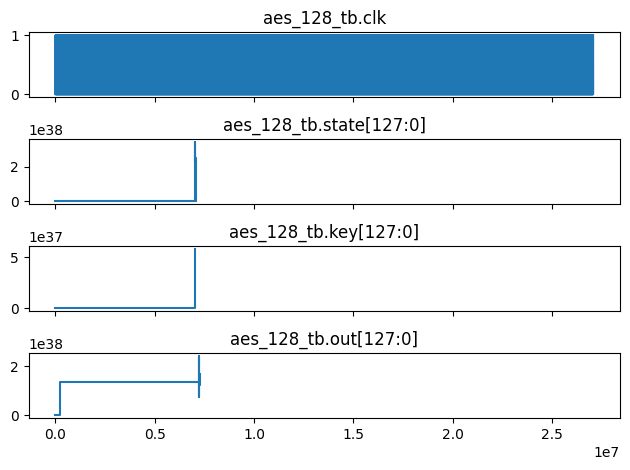

In [7]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt

vcd = VCDVCD('wave.vcd')
signals = ['aes_128_tb.clk',
           'aes_128_tb.state[127:0]',
           'aes_128_tb.key[127:0]',
           'aes_128_tb.out[127:0]']

fig, axes = plt.subplots(len(signals), 1, sharex=True)

for sig, ax in zip(signals, axes):
    times, raw_vals = zip(*vcd[sig].tv)
    # Step 1: convert '0'/'1' to int, 'x' to None
    raw_y = [int(v, 2) if v != 'x' else None for v in raw_vals]

    # Step 2: fill None with the last seen value (or 0 if at start)
    filled_y = []
    last = raw_y[0] if raw_y[0] is not None else 0
    for v in raw_y:
        if v is None:
            filled_y.append(last)
        else:
            filled_y.append(v)
            last = v

    # Step 3: plot and pad the axis
    ax.step(times, filled_y, where='post', label=sig)
    ax.set_title(sig)
    ax.relim()
    ax.autoscale_view()
    ax.margins(y=0.05)

    #
    if sig == 'aes_128_tb.key[127:0]':
        print(f"Key at time {times[-1]} ns: {''.join(format(x, '02x') for x in filled_y[-16:])}")
    elif sig == 'aes_128_tb.out[127:0]':
        print(f"Output at time {times[-1]} ns: {''.join(format(x, '02x') for x in filled_y[-16:])}")

(7255000, '1111101111101110110101100001100000110101011100010011001101100110011111001000010111100000100011110111001000110110101010001101111')
print ("As you can see they keys match the output AFTER the trigger signal")


fig.tight_layout()
plt.show()
